In [68]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import matplotlib.ticker as ticker
pd.set_option('display.float_format', '{:,.2f}'.format)

## Контекст

Яндекс Командировки — аналитическая команда сервиса корпоративных командировок.  
Компании подключают сервис для бронирования перелётов, отелей, железнодорожных билетов и такси для своих сотрудников.  
Ключевые метрики: GMV (оборот), количество бронирований, активные клиенты.  
**GMV** считается как сумма `amount_rub` по бронированиям со статусом `confirmed`.  
Работаю с синтетическим датасетом, содержащим данные о бронированиях и корпоративных клиентах.

## Загрузка и начальная обработка данных

**Cсылка на датасет:** https://disk.360.yandex.ru/client/aa/d_UNxhM7TV1BNQig

In [69]:
!gdown 1NK4_wFistr70jfvC_AAXkie-D0mNWDvN
!gdown 1u5FhoSbAx6iJwQUu-rQFE2waLlKa9kvA

Downloading...
From: https://drive.google.com/uc?id=1NK4_wFistr70jfvC_AAXkie-D0mNWDvN
To: /Users/gasikviktor2008/Yandex_BT/bookings.csv
100%|████████████████████████████████████████| 175k/175k [00:00<00:00, 8.24MB/s]
Downloading...
From: https://drive.google.com/uc?id=1u5FhoSbAx6iJwQUu-rQFE2waLlKa9kvA
To: /Users/gasikviktor2008/Yandex_BT/clients.csv
100%|██████████████████████████████████████| 2.69k/2.69k [00:00<00:00, 4.21MB/s]


In [70]:
bookings = pd.read_csv('/Users/gasikviktor2008/bookings.csv')
bookings.head()

,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to
0,1,1,train,2025-07-18,2025-07-20,"3,420.52",confirmed,Новосибирск,Сочи
1,2,5,train,2025-01-10,2025-01-17,"14,108.65",confirmed,Москва,Санкт-Петербург
2,3,36,hotel,2025-04-14,2025-04-29,"34,857.82",cancelled,Екатеринбург,Москва
3,4,18,avia,2025-07-17,2025-07-18,"24,844.33",confirmed,Екатеринбург,Казань
4,5,36,hotel,2025-04-24,2025-05-09,"58,959.96",confirmed,Уфа,Новосибирск


**Таблица** `bookings.csv`**отражает информацию о бронированиях.</br>
Одна строка - одна бронь. В данных представлены 9 признаков.**  
  
`booking_id` - | int | Идентификатор бронирования   
`client_id` - | int | Идентификатор клиента  
`subproduct` - | str | Субпродукт: **hotel**, **avia**, **train**, **taxi**  
`booking_date` - | date (YYYY-MM-DD) | Дата бронирования  
`trip_date` - | date | Дата поездки  
`amount_rub` - | float | Сумма бронирования в рублях   
`status` - | str | Статус: **confirmed** (оплачено) или **cancelled** (отменено)  
`city_from` - | str | Город отправления  
`city_to` - | str | Город назначения  

In [71]:
#Узнаем число строк, столбцов, типы данных. Проверим столбцы на пропуски и дубликаты. 
print(bookings.shape)
print(bookings.dtypes)
print(bookings.isna().sum())
print(bookings['booking_id'].is_unique)

(1964, 9)
booking_id        int64
client_id         int64
subproduct       object
booking_date     object
trip_date        object
amount_rub      float64
status           object
city_from        object
city_to          object
dtype: object
booking_id      0
client_id       0
subproduct      0
booking_date    0
trip_date       0
amount_rub      0
status          0
city_from       0
city_to         0
dtype: int64
True


In [72]:
#Преобразуем даты в форматы datetime и категориальные переменные в формат в category
bookings['booking_date'] = pd.to_datetime(bookings['booking_date'])
bookings['trip_date'] = pd.to_datetime(bookings['trip_date'])
bookings['subproduct'] = bookings['subproduct'].astype('category')
bookings['status'] = bookings['status'].astype('category')

In [73]:
#Проверим min и max значения столбцов bookings['booking_date'] и bookings['amount_rub'], чтоб выявить нелогичные значения в случае чего
print(bookings['booking_date'].min(), bookings['booking_date'].max())
print(bookings['amount_rub'].min(), bookings['amount_rub'].max())

2025-01-01 00:00:00 2025-12-28 00:00:00
303.12 219434.02


In [74]:
clients = pd.read_csv('/Users/gasikviktor2008/clients.csv')
clients.head()

,client_id,company_name,tier,industry,first_booking_date
0,1,АльфаГрупп,2,Финансы,2024-09-04
1,2,БетаЛогистик,3,Ритейл,2024-02-18
2,3,ГаммаТех,3,Ритейл,2024-11-20
3,4,ДельтаФинанс,2,Логистика,2024-10-07
4,5,ЕпсилонСтрой,3,IT,2024-01-22


**Таблица** `clients.csv`**отражает информацию о корпоративных клиентах.</br>
Одна строка - один клиент. В данных представлены 5 признаков.**

`client_id` - | int | Идентификатор клиента  
`company_name` - | str | Название компании  
`tier` - | int | Тир клиента: 1 — крупный, 2 — средний, 3 — малый  
`industry` - | str | Отрасль  
`first_booking_date` - | date (YYYY-MM-DD) | Дата первого бронирования (может быть до 2025 года)  


In [75]:
#Узнаем число строк, столбцов, типы данных. Проверим столбцы на пропуски и дубликаты. 
print(clients.shape)
print(clients.dtypes)
print(clients['client_id'].is_unique)
print(clients['company_name'].is_unique)

(50, 5)
client_id              int64
company_name          object
tier                   int64
industry              object
first_booking_date    object
dtype: object
True
True


In [76]:
#Преобразуем даты в форматы datetime 
clients['first_booking_date'] = pd.to_datetime(clients['first_booking_date'])

## Задания

### Блок 1 — SQL или Python/pandas
**Для выполнения заданий буду использовать sqlite3.**

In [77]:
# Подключение к базе данных SQLite
con = sqlite3.connect('/Users/gasikviktor2008/Desktop/Yandex/database.sqlit')

# Загрузка датафреймов в таблицы базы данных
bookings.to_sql('bookings', con, if_exists='replace', index=False)
clients.to_sql('clients', con, if_exists='replace', index=False)

50

**Задание 1.** Рассчитай GMV и количество бронирований (`confirmed`) по каждому субпродукту помесячно за 2025 год.  
Ответь: какой субпродукт генерирует наибольший оборот и есть ли явная сезонность?

**Рассчитаем GMV и количество бронирований (confirmed) по каждому субпродукту помесячно за 2025 год**

In [78]:
result = pd.read_sql_query("""
SELECT 
subproduct, 
strftime('%m', booking_date) AS month,
SUM(amount_rub) AS gmv,
COUNT(booking_id) as booking_number
FROM bookings 
WHERE booking_date >= '2025-01-01' AND booking_date < '2026-01-01' AND status = 'confirmed'
GROUP BY subproduct, strftime('%m', booking_date)
""", con)

print(result)

   subproduct month          gmv  booking_number
0        avia    01 3,465,491.28              43
1        avia    02 4,821,583.41              60
2        avia    03 5,966,560.92              76
3        avia    04 4,545,435.50              59
4        avia    05 4,624,326.74              67
5        avia    06 7,474,322.49             104
6        avia    07 4,638,029.35              58
7        avia    08 3,665,833.59              51
8        avia    09 2,915,620.05              30
9        avia    10 3,069,933.92              35
10       avia    11 3,502,674.18              34
11       avia    12 2,616,031.97              33
12      hotel    01 1,658,369.43              37
13      hotel    02 2,276,832.71              48
14      hotel    03 2,748,759.23              54
15      hotel    04 2,710,065.74              57
16      hotel    05 3,054,544.17              63
17      hotel    06 3,481,068.91              69
18      hotel    07 2,732,435.42              54
19      hotel    08 

**Посмотрю доли субпродуктов в годовом обороте компании, чтоб найти самый прибыльный субпродукт**

In [79]:
#Рассчёт долей субпродуктов в годовом обороте компании
result = pd.read_sql_query("""
WITH monthly_data AS (
SELECT 
subproduct, 
strftime('%m', booking_date) AS month,
SUM(amount_rub) AS gmv,
COUNT(booking_id) as booking_number
FROM bookings 
WHERE booking_date >= '2025-01-01' AND booking_date < '2026-01-01' AND status = 'confirmed'
GROUP BY subproduct, strftime('%m', booking_date)
),
tot AS (
SELECT 
subproduct, 
month, 
gmv, 
booking_number,
SUM(gmv) OVER (PARTITION BY subproduct) AS year_gmv,
SUM(gmv) OVER () AS total
FROM monthly_data
)
SELECT 
subproduct, 
month, 
gmv, 
booking_number,
year_gmv,
ROUND(year_gmv * 100.0 / total, 2) AS year_gmv_perc
FROM tot
""", con)
print(result)

   subproduct month          gmv  booking_number      year_gmv  year_gmv_perc
0        avia    01 3,465,491.28              43 51,305,843.40          60.57
1        avia    02 4,821,583.41              60 51,305,843.40          60.57
2        avia    03 5,966,560.92              76 51,305,843.40          60.57
3        avia    04 4,545,435.50              59 51,305,843.40          60.57
4        avia    05 4,624,326.74              67 51,305,843.40          60.57
5        avia    06 7,474,322.49             104 51,305,843.40          60.57
6        avia    07 4,638,029.35              58 51,305,843.40          60.57
7        avia    08 3,665,833.59              51 51,305,843.40          60.57
8        avia    09 2,915,620.05              30 51,305,843.40          60.57
9        avia    10 3,069,933.92              35 51,305,843.40          60.57
10       avia    11 3,502,674.18              34 51,305,843.40          60.57
11       avia    12 2,616,031.97              33 51,305,843.40  

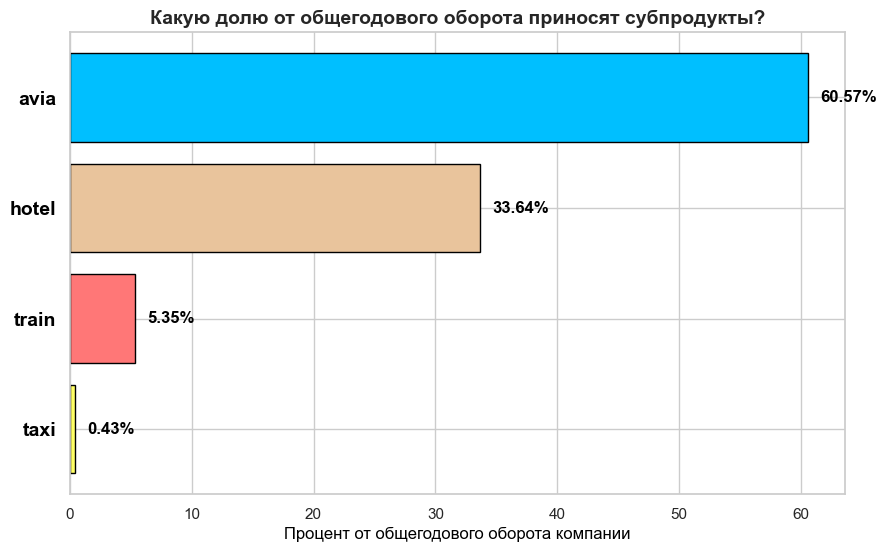

In [80]:
#горизонтальная столбчатая диаграмма, сопоставляющая доли субпродуктов от годового дохода
unique_clmns = result[['subproduct', 'year_gmv_perc']].drop_duplicates()
unique_clmns = unique_clmns.sort_values(by='year_gmv_perc', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#FFFF66', '#FF7777', '#e9c49c', '#00BFFF']
bars = plt.barh(unique_clmns['subproduct'], unique_clmns['year_gmv_perc'], color=colors, edgecolor='black')
plt.yticks(fontsize=14, fontweight='bold', color='black')
for i, (bar, value) in enumerate(zip(bars, unique_clmns['year_gmv_perc'])):
    plt.text(value + 1, i, f'{value}%', va='center', fontsize=12, fontweight='bold', color="black")
plt.title('Какую долю от общегодового оборота приносят субпродукты?', fontsize=14, fontweight='bold')
plt.xlabel('Процент от общегодового оборота компании', fontsize=12, color="black")

plt.savefig('subproduct_income_part.png', dpi=300, bbox_inches='tight')
plt.show()

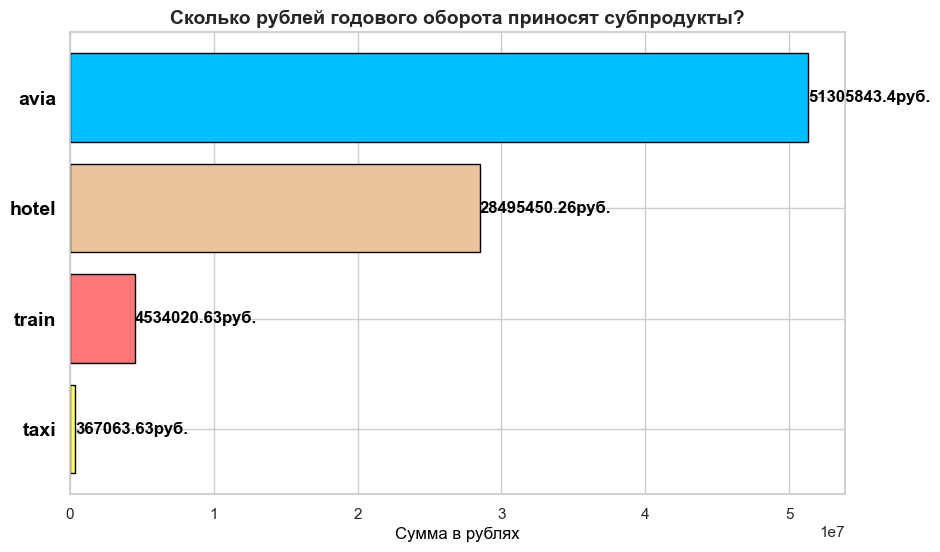

In [81]:
#горизонтальная столбчатая диаграмма, сопоставляющая суммы годового дохода по субпродуктам
unique_clmns1 = result[['subproduct', 'year_gmv']].drop_duplicates()
unique_clmns1 = unique_clmns1.sort_values(by='year_gmv', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#FFFF66', '#FF7777', '#e9c49c', '#00BFFF']
bars = plt.barh(unique_clmns1['subproduct'], unique_clmns1['year_gmv'], color=colors, edgecolor='black')
plt.yticks(fontsize=14, fontweight='bold', color='black')
for i, (bar, value) in enumerate(zip(bars, unique_clmns1['year_gmv'])):
    plt.text(value + 1, i, f'{value}руб.', va='center', fontsize=12, fontweight='bold', color="black")
plt.title('Сколько рублей годового оборота приносят субпродукты?', fontsize=14, fontweight='bold')
plt.xlabel('Сумма в рублях', fontsize=12, color="black")

plt.show()


**На представленных диаграммах четко видно, что субпродукт avia приносит наибольший доход. Доля субпродукта avia во всем годовом доходе компании равняется 60,57%.**

**Построю линейные графики помесячной динамики gmv в разрезе субпродуктов, чтоб посмотреть, есть ли сезонность.**

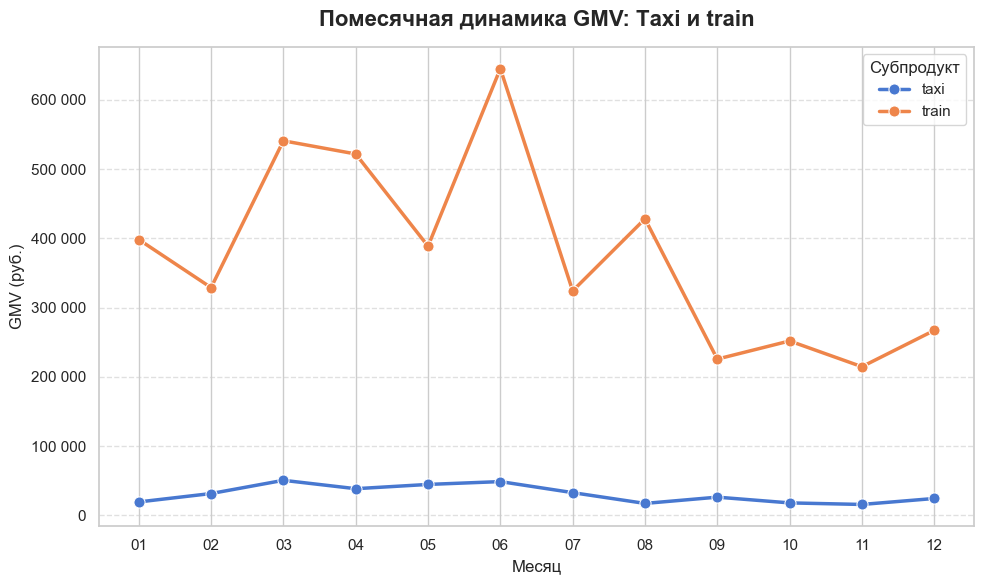

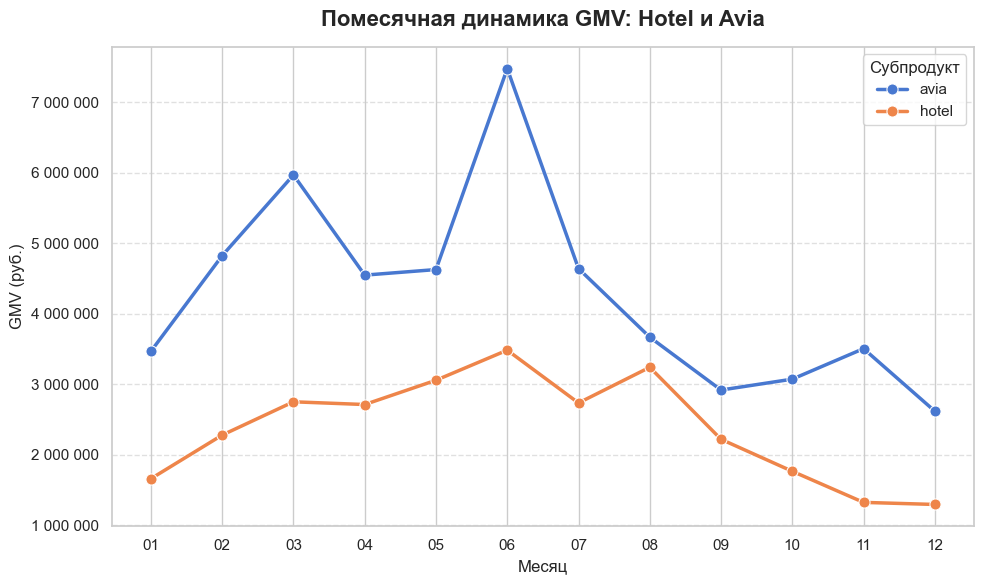

In [82]:
result['month'] = result['month'].astype(int)

#Форматирую график
month_labels = [f'{i:02d}' for i in range(1, 13)]
def format_y_axis(x, pos):
    return f'{x:,.0f}'.replace(',', ' ')
sns.set_theme(style="whitegrid", palette="muted")

#Cтрою график динамики gmv для такси и поезда

taxi_train = result[result['subproduct'].isin(['taxi', 'train'])]

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=taxi_train, 
    x='month', 
    y='gmv', 
    hue='subproduct',    
    marker='o',           
    linewidth=2.5,
    markersize=8
)

plt.title('Помесячная динамика GMV: Тaxi и train', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('GMV (руб.)', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=month_labels, fontsize=11)
plt.yticks(fontsize=11)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_y_axis))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Субпродукт', fontsize=11, title_fontsize=12)
plt.tight_layout()

plt.savefig('cancelled_bookings_perc2.png', dpi=300, bbox_inches='tight')
plt.show()


#Cтрою график динамики gmv для самолета и отелей
plane_hotel = result[result['subproduct'].isin(['avia', 'hotel'])]

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=plane_hotel, 
    x='month', 
    y='gmv', 
    hue='subproduct',    
    marker='o',           
    linewidth=2.5,
    markersize=8
)

plt.title('Помесячная динамика GMV: Hotel и Avia', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('GMV (руб.)', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=month_labels, fontsize=11)
plt.yticks(fontsize=11)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_y_axis))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Субпродукт', fontsize=11, title_fontsize=12)
plt.tight_layout()

plt.savefig('gmv_dynamic.png', dpi=300, bbox_inches='tight')
plt.show()

**На основе данных графиков можно сделать вывод, что по всем продуктам наблюдается тренд: Первые 3 месяца года gmv субпродуктов avia, hotel и train растет, в июне мы видим пиковые значения gmv по всем продуктам (6 месяц), а во второй половине года (начная с июля) gmv субпродуктов avia, hotel и train снижается, субпродукт taxi также показывает негативную динамику, но не настолько выраженную.**

**Задание 2. Найди топ-10 клиентов по GMV за весь 2025 год. Для каждого покажи: GMV, количество бронирований, средний чек, тир клиента, отрасль.**

In [96]:
result = pd.read_sql_query("""
SELECT 
SUM(amount_rub) AS gmv,
bo.client_id,
COUNT(bo.booking_id) as booking_number,
AVG(bo.amount_rub) as avg_check,
cl.tier,
cl.industry	
FROM bookings bo JOIN clients cl ON bo.client_id = cl.client_id 
WHERE booking_date >= '2025-01-01' AND booking_date < '2026-01-01' AND status = 'confirmed'
GROUP BY bo.client_id
ORDER BY gmv DESC LIMIT 10
""", con)

print(result)

            gmv  client_id  booking_number  avg_check  tier       industry
0 10,563,335.21         27             131  80,636.15     1             IT
1  9,223,178.42         23             115  80,201.55     1             IT
2  7,999,757.55         19              98  81,630.18     1  Строительство
3  7,243,077.04         33              83  87,265.99     1  Строительство
4  3,618,567.71          1              70  51,693.82     2        Финансы
5  2,909,819.99         34              60  48,497.00     2      Логистика
6  2,839,605.26         17              63  45,073.10     2      Логистика
7  2,734,558.07         21              64  42,727.47     2        Финансы
8  2,649,892.99         45              62  42,740.21     2         Ритейл
9  2,616,726.17          4              53  49,372.19     2      Логистика


**Задание 3. Посчитай долю отмен (`cancelled / всего`) по субпродуктам. Укажи, если есть субпродукт с заметно более высокой долей отмен, и предложи гипотезу — почему.**

In [97]:
result = pd.read_sql_query("""
SELECT 
    subproduct,
    COUNT(CASE WHEN status = 'cancelled' THEN 1 END) * 1.0 / COUNT(*) * 100 AS cancelled_perc
    FROM bookings
    GROUP BY subproduct
    ORDER BY cancelled_perc DESC
""", con)

print(result)

  subproduct  cancelled_perc
0       avia           15.25
1      train           13.72
2      hotel           13.32
3       taxi           10.77


**Построим вертикальную столбчатую диаграмму, отражающую доли отмененных бронирований по субпродуктам.**

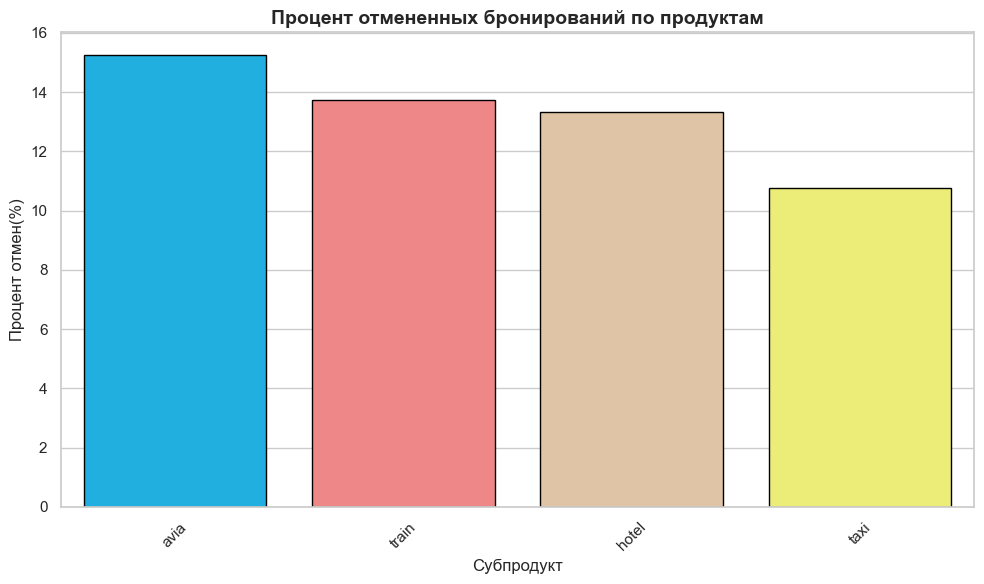

In [98]:
result = result.sort_values(by='cancelled_perc', ascending=False)
colors = ['#00BFFF', '#FF7777','#e9c49c',  '#FFFF66']
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='subproduct', y='cancelled_perc', palette=colors,  hue='subproduct', legend=False, edgecolor='black')
plt.title('Процент отмененных бронирований по продуктам', fontsize=14, fontweight='bold')
plt.xlabel('Субпродукт', fontsize=12)
plt.ylabel('Процент отмен(%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('cancelled_bookings_perc.png', dpi=300, bbox_inches='tight')
plt.show()

**Субпродукт avia обладает наибольшей долей возвратов 15,25.   
Это на ~2% больше чем доли отмен по hotel и по train (доля отмен по hotel 13.22%,  по train 13.72%  cоответсвенно).  
Моя гипотеза в том, что доля отмен по avia является самой большой в силу дороговизны авиабилетов и частых переносов/отмен рейсов.**

### Блок 2. Бизнес-анализ.

**Задание 4. Есть гипотеза: клиенты тира 1 бронируют более дорогие продукты, но реже, чем клиенты тира 3. Проверь гипотезу данными. Подтвердилась ли она? Что ещё интересного ты заметил(-а) при анализе тиров?**

Для выполнения этой задачи  данного блока я буду использовать python.
Для начала замерджу таблицы `bookings.csv` и `clients.csv`:

In [86]:
data = bookings.merge(
    clients,
    on="client_id",
    how="left",
    validate="many_to_one"
)
data.head()

,booking_id,client_id,subproduct,booking_date,trip_date,amount_rub,status,city_from,city_to,company_name,tier,industry,first_booking_date
0,1,1,train,2025-07-18,2025-07-20,"3,420.52",confirmed,Новосибирск,Сочи,АльфаГрупп,2,Финансы,2024-09-04
1,2,5,train,2025-01-10,2025-01-17,"14,108.65",confirmed,Москва,Санкт-Петербург,ЕпсилонСтрой,3,IT,2024-01-22
2,3,36,hotel,2025-04-14,2025-04-29,"34,857.82",cancelled,Екатеринбург,Москва,ТехноПром,3,Ритейл,2024-11-18
3,4,18,avia,2025-07-17,2025-07-18,"24,844.33",confirmed,Екатеринбург,Казань,СигмаЭнерго,3,Ритейл,2024-06-13
4,5,36,hotel,2025-04-24,2025-05-09,"58,959.96",confirmed,Уфа,Новосибирск,ТехноПром,3,Ритейл,2024-11-18


In [87]:
data = bookings.merge(
    clients,
    on="client_id",
    how="left",
    validate="many_to_one"
)

#Проверка есть ли в итоге ID клиентов без бронирований
data["tier"].isna().mean()
data[data["tier"].isna()]["client_id"].nunique()

0

Разобью гипотезу на 2 части:  
**1) Клиенты тира 1 бронируют более дорогие продукты.  
2) Клиенты тира 3 бронируют чаще клиентов тира 3.**   
Эти получившиеся новые гипотезы и буду проверять.

Для сравнений отберем данные только по подтверждённым бронированиям (`status` = 'confirmed') и для каждого тира 
составим таблицу агрегированных по `client_id` данных.   
Таким образом найдем средние и медианные чеки и число бронирований по каждому клиенту тира 1 и 3 соответственно. В итоге получим 2 набора данных: по первому тиру и по 3 тиру.  

In [88]:
#Тир 3
data_tier3 = data[(data['tier'] == 3) & (data['status'] == 'confirmed')]
tier3 = data_tier3.groupby('client_id').agg(
    avg_check=('amount_rub', 'mean'),
    median_check=('amount_rub', 'median'),
    booking_numb =('booking_id', 'count')
).reset_index()

tier3.head()

,client_id,avg_check,median_check,booking_numb
0,2,"20,024.60","12,907.37",5
1,3,"17,134.69","6,941.76",7
2,5,"19,197.48","15,392.42",6
3,6,"38,847.03","40,088.26",12
4,7,"21,465.83","14,562.18",12


In [89]:
#Тир 1
data_tier1 = data[(data['tier'] == 1) & (data['status'] == 'confirmed')]
tier1 = data_tier1.groupby('client_id').agg(
    avg_check=('amount_rub', 'mean'),
    median_check=('amount_rub', 'median'),
    booking_numb =('booking_id', 'count')
).reset_index()

tier1.head()

,client_id,avg_check,median_check,booking_numb
0,19,"81,630.18","73,867.29",98
1,23,"80,201.55","60,812.71",115
2,27,"80,636.15","77,729.40",131
3,33,"87,265.99","81,399.08",83


**Один набор содержит 29 объектов, другой 4**   
Посмотрим, равны ли дисперсии наборов, и являются ли распредления данных нормальными (эйкей уместен ли t-тест Уэлша при сравнении средних). Также посмотрим на формы распредлений. Для этого я построб Box-plot распределений средних чеков по клиентам 1 тира и 3 тира, медианных чеков по клиентам 1 тира и 3 тира и количеств бронирований и быстро посмотрю описательные статистики.

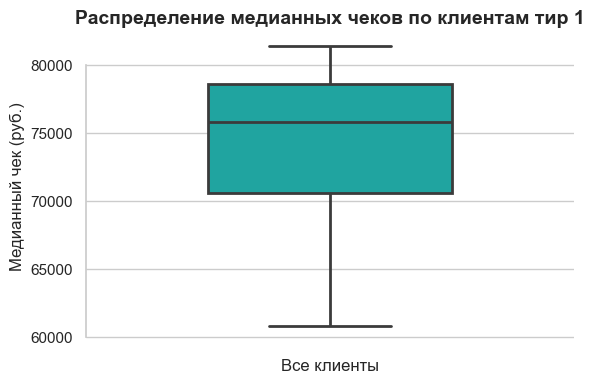

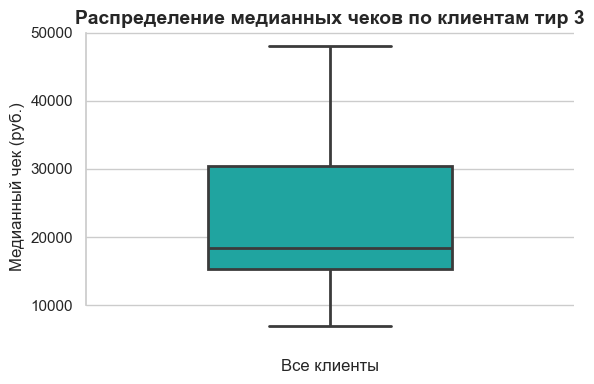

In [90]:
#Распрелеоения медианных чеков в тире 1 и тире 3 

#Тир 1
plt.figure(figsize=(6, 4))
sns.boxplot(y=tier1['median_check'], color='#0abab5', linewidth=2, width=0.5) 
plt.title('Распределение медианных чеков по клиентам тир 1', fontsize=14, fontweight='bold')
plt.ylabel('Медианный чек (руб.)', fontsize=12)
plt.xlabel('Все клиенты', fontsize=12)
sns.despine(trim=True)
plt.tight_layout()

plt.show()

#Тир 3
plt.figure(figsize=(6, 4))
sns.boxplot(y=tier3['median_check'], color='#0abab5', linewidth=2, width=0.5)
plt.title('Распределение медианных чеков по клиентам тир 3', fontsize=14, fontweight='bold')
plt.ylabel('Медианный чек (руб.)', fontsize=12)
plt.xlabel('Все клиенты', fontsize=12)
sns.despine(trim=True)
plt.tight_layout()

plt.show()

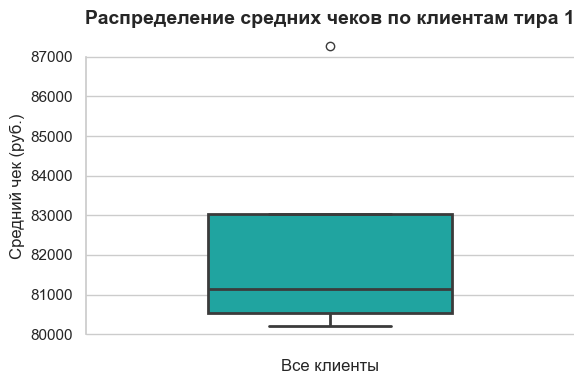

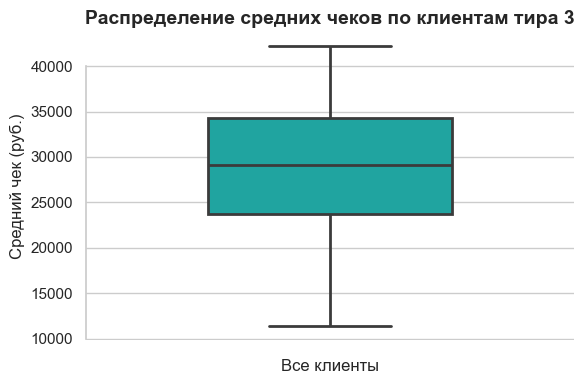

In [91]:
#Распредеоения средних чеков в тире 1 и тире 3 

#Тир 1
plt.figure(figsize=(6, 4))
sns.boxplot(y=tier1['avg_check'], color='#0abab5', linewidth=2, width=0.5) 
plt.title('Распределение средних чеков по клиентам тира 1', fontsize=14, fontweight='bold')
plt.ylabel('Средний чек (руб.)', fontsize=12)
plt.xlabel('Все клиенты', fontsize=12)
sns.despine(trim=True)
plt.tight_layout()

plt.show()

#Тир 3
plt.figure(figsize=(6, 4))
sns.boxplot(y=tier3['avg_check'], color='#0abab5', linewidth=2, width=0.5)
plt.title('Распределение средних чеков по клиентам тира 3', fontsize=14, fontweight='bold')
plt.ylabel('Средний чек (руб.)', fontsize=12)
plt.xlabel('Все клиенты', fontsize=12)
sns.despine(trim=True)
plt.tight_layout()

plt.show()

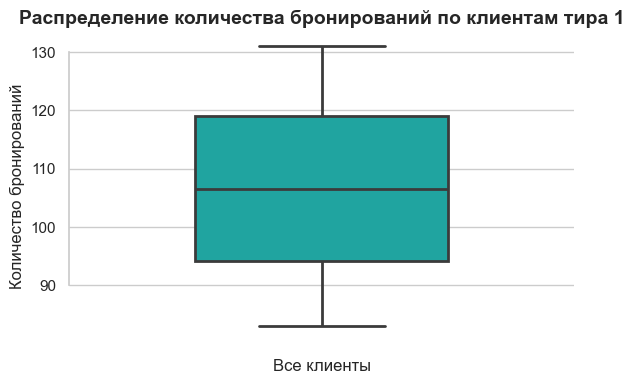

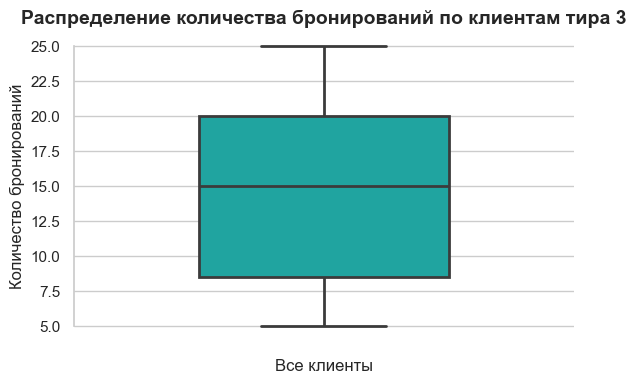

In [92]:
#Распределения заказов на клиента в тире 1 и тире 3 

#Тир 1
plt.figure(figsize=(6, 4))
sns.boxplot(y=tier1['booking_numb'], color='#0abab5', linewidth=2, width=0.5) 
plt.title('Распределение количества бронирований по клиентам тира 1', fontsize=14, fontweight='bold')
plt.ylabel('Количество бронирований', fontsize=12)
plt.xlabel('Все клиенты', fontsize=12)
sns.despine(trim=True)
plt.tight_layout()

plt.show()

#Тир 3
plt.figure(figsize=(6, 4))
sns.boxplot(y=tier3['booking_numb'], color='#0abab5', linewidth=2, width=0.5)
plt.title('Распределение количества бронирований по клиентам тира 3', fontsize=14, fontweight='bold')
plt.ylabel('Количество бронирований', fontsize=12)
plt.xlabel('Все клиенты', fontsize=12)
sns.despine(trim=True)
plt.tight_layout()

plt.show()

In [93]:
#Описательная статистика по набору 1 тира
print(stats.describe(tier1['median_check']))
print()
print(stats.describe(tier1['avg_check']))
print()
print(stats.describe(tier1['booking_numb']))

DescribeResult(nobs=np.int64(4), minmax=(np.float64(60812.71), np.float64(81399.08)), mean=np.float64(73452.12), variance=np.float64(80458782.90566666), skewness=np.float64(-0.7674456286803684), kurtosis=np.float64(-0.9510162500242498))

DescribeResult(nobs=np.int64(4), minmax=(np.float64(80201.55147826087), np.float64(87265.98843373494)), mean=np.float64(82433.46640871245), variance=np.float64(10736780.75185378), skewness=np.float64(1.0438622350624893), kurtosis=np.float64(-0.7598530642577739))

DescribeResult(nobs=np.int64(4), minmax=(np.int64(83), np.int64(131)), mean=np.float64(106.75), variance=np.float64(432.25), skewness=np.float64(0.032363235154453864), kurtosis=np.float64(-1.3955895656300514))


In [94]:
#Описательная статистика по набору 3 тира
print(stats.describe(tier3['median_check']))
print()
print(stats.describe(tier3['avg_check']))
print()
print(stats.describe(tier3['booking_numb']))

DescribeResult(nobs=np.int64(30), minmax=(np.float64(6941.76), np.float64(47973.005000000005)), mean=np.float64(23090.432333333334), variance=np.float64(128716832.54716851), skewness=np.float64(0.6617782222817788), kurtosis=np.float64(-0.7085152571083144))

DescribeResult(nobs=np.int64(30), minmax=(np.float64(11350.22), np.float64(42179.25125)), mean=np.float64(28560.33494381035), variance=np.float64(56992034.300829716), skewness=np.float64(-0.21446240518557774), kurtosis=np.float64(-0.655474206018706))

DescribeResult(nobs=np.int64(30), minmax=(np.int64(5), np.int64(25)), mean=np.float64(14.4), variance=np.float64(40.04137931034484), skewness=np.float64(0.017806399711200203), kurtosis=np.float64(-1.297949820638823))


На основе результатов нашей проверки мы видим, что данные сильно различаются.   
В случае сравнения средних трат на бронирование по клиенту: данные по клиентам тира 3 сгруппированы плотнее вокруг среднего значения, что свидетельствует о неравенстве дисперсий. Также межквартильный размах 3 тира шире межквартильного размаха 1 тира.
В выборке по клиентам тира 1 среди 4 значений одно из значений явялется выбросом, что в купе с размером выборки мешает допущению о нормальности распределений выборочных значений.   
Также неравенство дисперсий и подверженность выборки выбросам заметны и в случаях с распредлениями числа бронирований и медианных трат.

Т.к. данные в обеих группах не являются нормально распредленными, а дисперсии выборок не равны, для проверки гипотез будем использовать тест Мана-Уитни для сравнения распределений значений в выборках по тиру 1 и тиру 3 и ответа на вопрос, а есть ли доминирование значений одной группы над значениями другой.

**Клиенты тира 1 бронируют более дорогие продукты.**  

H0: Cредние чеки клиентов 1 тира и клиентов 3 тира  одинаковы.  
H1: Средние чеки клиентов 1 тира статистически значимо больше чеков клиентов 3 тира.

In [56]:
alpha = 0.05

res1 = stats.mannwhitneyu(tier1['avg_check'], tier3['avg_check'], alternative='greater', method='exact')
print(f'Тест 1 (check) P-value: {res1.pvalue}')
if res1.pvalue < alpha:
    print("H0 отвергается")
else:
    print("H0 не отвергается")

Тест 1 (check) P-value: 2.156287735035363e-05
H0 отвергается


**На 5% уровне значимости полученные данные дают достаточные основания для отклонения нулевой гипотезы (p = 2.156287735035363e-05).  
Мы делаем вывод, что чеки клиентов 1 тира больше чеков клиентов 3 тира.**

**Клиенты тира 3 бронируют чаще клиентов тира 1.**  

H0: Количества заказов клиентов 1 тира и клиентов 3 тира одинаковы.  
H1: Количества заказов 1 тира статистически значимо меньше количества заказов 3 тира.

In [57]:
alpha = 0.05
statistic, pvalue = stats.mannwhitneyu(tier1['booking_numb'], tier3['booking_numb'], alternative='less', method='exact')

print(f'Тест 1 (booking_numb) P-value: {res1.pvalue}')
if res1.pvalue < alpha:
    print("H0 отвергается")
else:
    print("H0 не отвергается")

Тест 1 (booking_numb) P-value: 2.156287735035363e-05
H0 отвергается


**На 5% уровне значимости полученные данные дают достаточные основания для отклонения нулевой гипотезы.  
Мы делаем вывод, что клиенты тира 1 в своей массе заказывают меньше клиентов тира 3.**

**Гипотеза подтвердилась. Клиенты тира 1 бронируют более дорогие продукты, но реже, чем клиенты тира 3.** 

**Задание 5.** Найди клиентов, у которых в первом полугодии 2025 года (январь–июнь) были бронирования, а во втором (июль–декабрь)  
— не было ни одного подтверждённого. Это потенциальный отток (churn). Сколько таких клиентов? Каков их суммарный GMV за H1? Какого они тира?

In [59]:
result = pd.read_sql_query("""
WITH H1_clients AS (
    SELECT DISTINCT client_id
    FROM bookings
    WHERE booking_date >= '2025-01-01' AND booking_date < '2025-07-01'
),
     H2_confirmed_clients AS (
    SELECT DISTINCT client_id
    FROM bookings
    WHERE booking_date >= '2025-07-01' AND booking_date < '2026-01-01' AND status = 'confirmed'
),
     churned_clients AS (
    SELECT client_id FROM H1_clients
EXCEPT
    SELECT client_id FROM H2_confirmed_clients
),
    churned_H1_table AS (
    SELECT 
        cl.client_id,
        cl.tier,
        SUM(CASE WHEN bo.status = "confirmed" THEN bo.amount_rub ELSE 0 END) AS H1_gmv
    FROM churned_clients cc JOIN clients cl ON cc.client_id = cl.client_id
    JOIN bookings bo ON cc.client_id = bo.client_id
    WHERE bo.booking_date >= '2025-01-01' AND bo.booking_date < '2025-07-01'
    GROUP BY cl.client_id, cl.tier
)
SELECT 
    tier,
    COUNT(client_id) AS churned_clients_count,
    ROUND(SUM(h1_gmv), 2) AS total_H1_gmv
FROM churned_H1_table
GROUP BY tier
""", con)

result

,tier,churned_clients_count,total_H1_gmv
0,2,6,"13,193,157.78"
1,3,10,"4,316,954.02"


**Это клиенты второго и третьего тиров, их 16 (6 - 2 тир, 10 - 3 тир), суммарный gmv за первую половину года ~17510111 рублей**

### Блок 3. Когортный анализ.

**Задание 6.**   
«Новый клиент» — тот, у кого `first_booking_date` приходится на 2025 год.  
Для каждого нового клиента определи месяц первой активности в 2025 году (когорту). Затем для каждой когорты покажи, сколько клиентов оставались активными в каждом из последующих месяцев (были хотя бы одно `confirmed` бронирование). Это retention-таблица.  
Интерпретируй: есть ли когорты, которые удерживаются лучше других?

**Начнем с того, что в файле `clients.csv` нет клиентов, с `first_booking_date`, приходящимся на 2025 год. 
Посмотрев на содержание файла `bookings.csv`, я понял, что по всем нашим клиентам есть данные о бронрованиях только за 2025 год 
(несмотря на то, что их первые заказы должны были быть совершены в 2024 году).
Я построил retention таблицу клиентов за 2025 год, допустив, что все клиенты из `clients.csv` совершили первый заказ в 2024 году а не в 2025. Иначе задание невозможно было бы решить**

Для начала я сделал длинную таблицу retention в абсолютных значениях с помощью sqlite

In [60]:
result = pd.read_sql_query("""
WITH first_booking AS (
SELECT
client_id,
strftime('%m', min(booking_date)) AS number
FROM bookings 
WHERE (booking_date >= '2025-01-01' AND booking_date < '2026-01-01') AND status = 'confirmed'
GROUP BY client_id),
montly_bookings AS (
SELECT DISTINCT
client_id, 
strftime('%m', booking_date) AS month
FROM bookings 
WHERE (booking_date >= '2025-01-01' AND booking_date < '2026-01-01') AND status = 'confirmed')
SELECT
    fb.number as cohort_num,
    mb.month,
    COUNT(DISTINCT mb.client_id) AS active_clients
FROM first_booking fb
JOIN montly_bookings mb ON fb.client_id = mb.client_id 
                    AND mb.month >= fb.number
GROUP BY fb.number, mb.month
ORDER BY fb.number, mb.month;

""", con)

result

,cohort_num,month,active_clients
0,01,01,36
1,01,02,30
2,01,03,32
3,01,04,32
4,01,05,33
5,01,06,33
6,01,07,23
7,01,08,21
8,01,09,20
9,01,10,20


Получившуюся таблицу я хотел превратить в сводную с помощью pd.pivot.  
Но для начала я хотел перевести месяцы наблюдений из абсолютных значений в относительные (начиная с момента первого действия).
Это необходимо для дальнейшего построения таблицы удержания в процентных значениях.

In [61]:
result['cohort_num'] = result['cohort_num'].astype(int)
result['month'] = result['month'].astype(int)

result['month_number'] = result['month'] - result['cohort_num'] 

retention_table = result.pivot(
    index = 'cohort_num',
    columns = 'month_number',
    values = 'active_clients'
)
retention_table.columns = [f'M{int(column)}' for column in retention_table.columns]

retention_table

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
cohort_num,,,,,,,,,,,,
1,36.00,30.00,32.00,32.00,33.00,33.00,23.00,21.00,20.00,20.00,17.00,18.00
2,10.00,9.00,6.00,9.00,9.00,5.00,6.00,4.00,4.00,3.00,6.00,NaN
3,4.00,NaN,4.00,2.00,2.00,3.00,4.00,4.00,2.00,2.00,NaN,NaN


In [62]:
#Из получившейся таблицы удержания делаю таблицу удержания в процентных значениях в сравнении с первым месяцам отсчета (M0)
cohort_sizes = retention_table['M0']
retention_perc = retention_table.div(
    cohort_sizes,
    axis = 0
) * 100
retention_perc

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
cohort_num,,,,,,,,,,,,
1,100.00,83.33,88.89,88.89,91.67,91.67,63.89,58.33,55.56,55.56,47.22,50.00
2,100.00,90.00,60.00,90.00,90.00,50.00,60.00,40.00,40.00,30.00,60.00,NaN
3,100.00,NaN,100.00,50.00,50.00,75.00,100.00,100.00,50.00,50.00,NaN,NaN


Визуализируем таблицу удержания с помощью хотмепа. Чем насыщеннее розовый цвет, тем больше процент удержания.

In [63]:
#Для покраски хитмэпа будем использовать мою гламурную палитру

from matplotlib.colors import LinearSegmentedColormap
hex_colors = ["#FFF8FA", "#F64A8A"] 
stacy_core = LinearSegmentedColormap.from_list("my_palette", hex_colors)

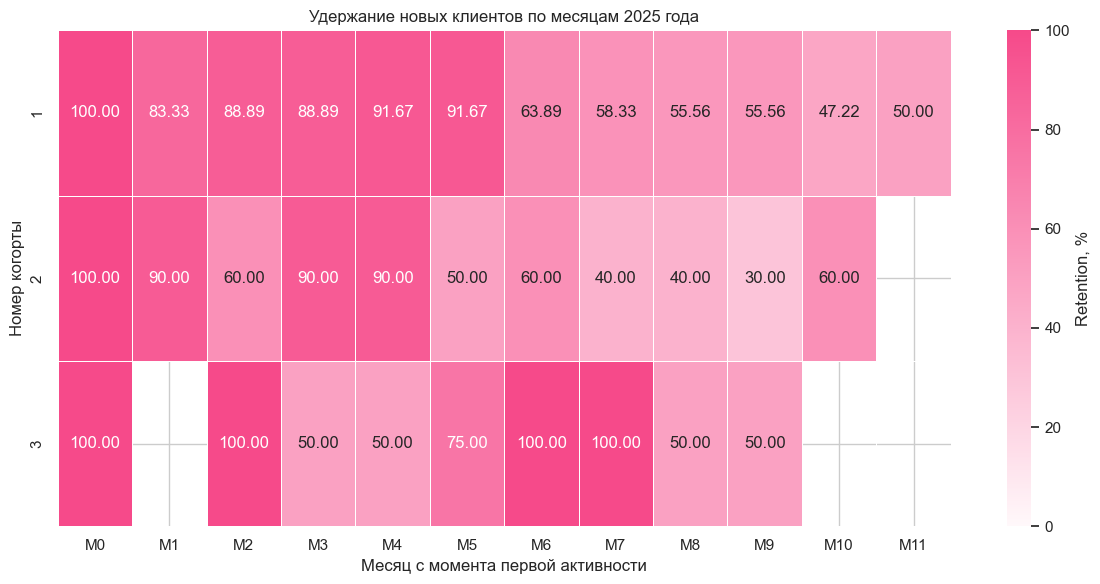

In [65]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention_perc,
    annot=True,
    fmt='.2f',
    cmap=stacy_core,
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Retention, %'}
)

plt.title('Удержание новых клиентов по месяцам 2025 года')
plt.xlabel('Месяц с момента первой активности')
plt.ylabel('Номер когорты')
plt.tight_layout()

plt.savefig('cohort_heat_map.png', dpi=300, bbox_inches='tight')
plt.show()

**На основе анализа хотмепа можно сделать вывод, что когорта 1 показывала лучшие значения удержания. Retention не упускалось ниже 47% ни разу за 12 месяцев наблюдений.**

Блок 4 — "Визуализация" и Блок 5 — "Выводы" будут в файле по cсылке:
https://drive.google.com/file/d/1NzgpZXcSiAlGINjMfLDn15Z0ZrlWzW-5/view?usp=sharing> и приложении]>